# HW 01: Park access
- **Subtitle:** Exploratory Data Analysis + Simple Linear Regression

- To submit this Activity, click the **Share** button in the top right hand corner of the screen, select "Edit" under "Anyone with a link to this project", and then copy the link into the corresponding Canvas assignment.

<div style="border:2px solid #b71c1c; background-color:#ffebee; padding:1em; border-radius:6px; color:#212121;"><strong>Warning</strong><br>

This document is scaffolded so that I have written portions of code with blanks for you to fill in. These code cells won't run properly until you fill them in. That means if you click the Run button at the beginning of the document, it won't make it to the bottom. It will stop when it hits the first incomplete coding exercise and give you an error. There is no problem with this, but be sure that the full document runs without error before turning it in.
</div>

## Introduction
This HW will go through much of the same workflow we've demonstrated in class. The main goal is to reinforce our demo of R and Jupyter notebooks, which we will be using throughout the course both to learn the statistical concepts and to analyze real data and come to informed conclusions.

<div style="border:2px solid #b71c1c; background-color:#ffebee; padding:1em; border-radius:6px; color:#212121;"><strong>Note</strong><br>
R is the name of the programming language itself and Jupyter notebooks are a convenient interface.
</div>

## Learning goals
By the end of this homework, you will...
- Be familiar with the workflow using Deepnote
- Gain practice writing a reproducible report using Jupyter notebooks
- Be able to create data visualizations using `ggformula` and use those visualizations to describe distributions
- Be able to fit, interpret, and evaluate simple linear regression models

# Packages
We will use the following packages in today's HW. As you work through this HW please delete these lines as you go.

In [1]:
library(tidyverse)
library(mosaic)
library(ggformula)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2


The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.


Attaching package: ‘mosaic’


The following object is masked from ‘package:Matrix’:

    mean


The following objects are masked from ‘package:dplyr’:

    count, d

# Data
Today's data is about access to parks and other public amenities in the 100 most populated cities in the United States. The data were collected by the [Trust for Public Land](https://www.tpl.org/parks-and-an-equitable-recovery-parkscore-report), a non-profit organization that advocates for equitable access to outdoor spaces. The data set we'll use in this HW includes part of the data used for analysis in the 2021 special report [*Parks and Equitable Recovery*](https://www.tpl.org/parks-and-an-equitable-recovery-parkscore-report); it was obtained from [TidyTuesday](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-06-22/readme.md).

This homework will focus on the following variables:

- `pct_near_park_points`: Points in the Trust for Public Land ParkScore index for the percent of residents within a 10 minute walk to park. [Click here](https://www.tpl.org/parkscore) to learn more about the ParkScore. **Note that this variable represents the number of points, not the percentage.**

- `spend_per_resident_data`: Spending per resident in US dollars.

[Click here](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-06-22/readme.md) for the full data dictionary.

# Exercises
**Goal**: One way to improve access to public parks is for cities to spend more money creating and maintaining parks for their residents. It's unclear, however, how much spending impacts residents' access to parks. The goal of this analysis is to examine the relationship between spending per resident and points in the ParkScore index for the percent of residents within a 10 minute walk to a park.

---
## Exercise 0
Use the code below to load the data into R.

In [2]:
parks <- read_csv("parks.csv")

Rows: 713 Columns: 28
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): city, park_pct_city_data, pct_near_park_data, spend_per_resident_d...
dbl (23): year, rank, med_park_size_data, med_park_size_points, park_pct_cit...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


---
## Exercise 1
Viewing a summary of the data is a useful starting point for data analysis, especially if there are a large number of observations or variables. Run the code below to use the `glimpse` function to see a summary of the `parks` data frame.

How many observations (rows) are in `parks`? How many variables (columns)?

In [3]:
# Insert code here
glimpse(parks)

Rows: 713
Columns: 28
$ year                      <dbl> 2020, 2020, 2020, 2020, 2020, 2020, 2020, 20…
$ rank                      <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…
$ city                      <chr> "Minneapolis", "Washington, D.C.", "St. Paul…
$ med_park_size_data        <dbl> 5.7, 1.4, 3.2, 2.4, 4.4, 4.9, 6.1, 1.3, 1.4,…
$ med_park_size_points      <dbl> 26, 5, 14, 10, 20, 22, 28, 4, 4, 9, 3, 21, 9…
$ park_pct_city_data        <chr> "15%", "24%", "15%", "11%", "14%", "18%", "2…
$ park_pct_city_points      <dbl> 38, 50, 39, 28, 36, 47, 50, 50, 45, 24, 50, …
$ pct_near_park_data        <chr> "98%", "98%", "99%", "99%", "82%", "90%", "8…
$ pct_near_park_points      <dbl> 98, 98, 99, 99, 74, 85, 73, 100, 100, 98, 99…
$ spend_per_resident_data   <chr> "$319", "$307", "$219", "$301", "$190", "$25…
$ spend_per_resident_points <dbl> 100, 100, 100, 100, 100, 100, 100, 100, 92, …
$ basketball_data           <dbl> 3.5, 6.3, 7.7, 7.9, 8.7, 3.4, 17.4, 4.2, 3.8…
$ basketball_point

There are 713 observations in "park" and 28 variables.

---
## Exercise 2
The predictor variable for this analysis `spend_per_resident_data` is quantitative; however, from the glimpse of the data in Exercise 1, we see its data type is `chr` (character) in R. We would expect it to be `dbl` (double), the data type for numeric data.

- Why did `spend_per_resident_data` get read by R as a character data type instead of a double? Be specific. Hint: Click on the parks data frame in the upper right hand panel to look at the data. Is there something about the data that might make R think it's not a number?
- Why do we need to convert `spend_per_resident_data` to a data type suitable for quantitative data? How might leaving it as a character variable hinder the analysis?

Using the $ charachter might make R think that its dealing with charachter instead of numbers. We need to convert it to a data type suitable for quantitative data because it will allow us to do calculations and analysis on the data otherwise its not really that useful. 

---
## Exercise 3
The code below to mutates `spend_per_resident_data` so that it is correctly treated as quantitative data in R. Each line of code is numbered. Write a brief explanation of what each line of code does. You may want to use the internet here to figure out the answer. If you do, don't forget to cite your source.

In [4]:
# Insert code here
parks <- parks |>  # <1>
  mutate(spend_per_resident_data = 
           str_replace(spend_per_resident_data,"\\$", "")) |> # <2>
  mutate(spend_per_resident_data = 
           as.numeric(spend_per_resident_data)) # <3>

1. Just a comment line
2. Putting the parks variable back into itself so that it actually changes.
3/4 replacing the $ sign with nothing so that it can be read as a number.
5/6 Converting the variable to a number.

---
## Exercise 4
Exploratory data analysis (EDA) helps us "get to know" the data and examine the variable distributions and relationships between variables. We do so using visualizations and summary statistics.

When we make visualizations, we want them to be clear and suitable for a professional audience. This means that, at a minimum, each visualization should have **an informative title** and **informative axis labels**.

Fill in the code below to visualize the distribution of `spend_per_resident_data` using a histogram.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


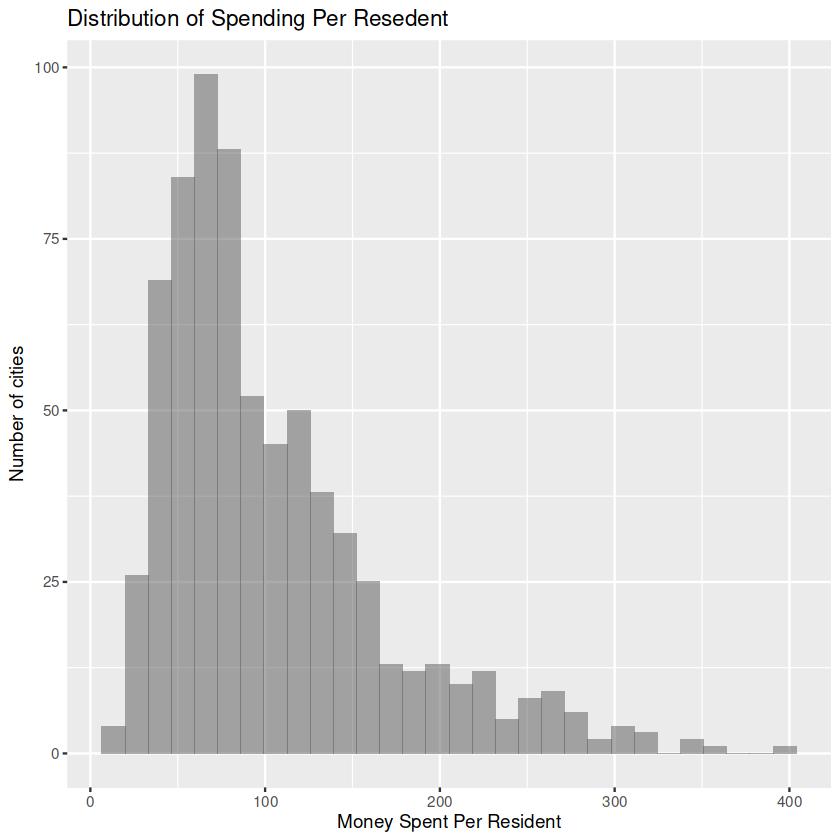

In [5]:
gf_histogram( ~ spend_per_resident_data, data = parks) |> 
  gf_labs(x = "Money Spent Per Resident",
       y = "Number of cities", 
       title = "Distribution of Spending Per Resedent ")

Then, fill in the code to calculate summary statistics for the variable using the `favstats` function from the mosaic R package.

In [6]:
favstats(~ spend_per_resident_data, data = parks) 

,min,Q1,median,Q3,max,mean,sd,n,missing
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
,15,59,84,131,399,103.8752,63.97614,713,0


---
## Exercise 5
Use the visualization and summary statistics from the previous exercise to describe the distribution of `spend_per_resident_data`. In your narrative, include a description of the shape, center, spread, and the presence of apparent outliers or other interesting features.

<div style="border:2px solid #b71c1c; background-color:#ffebee; padding:1em; border-radius:6px; color:#212121;">

**Feedback — Exercise 5**  <br>
What I saw: Narrative states the distribution is left-skewed and mentions mean≈104, median≈84, and high values near 399.  <br>
What’s missing or off: Shape is misidentified — the histogram and favstats indicate right-skew (long right tail). Spread (IQR≈72) and comment on high-end outliers need explicit mention.  <br>
How to improve: Describe shape as right-skewed; report center (mean≈104, median≈84) and spread (IQR≈131−59≈72), and note possible high-end outliers near 399.  <br>
Why it matters: Accurate descriptions connect visuals/statistics to clear, professional communication.
</div>

The dataset shows a skewed left bell curve with the mean being ~104 and the median being 84 and outliers all the way to 400.

---
## Exercise 6
Now let's look at the distribution of the response variable `pct_near_park_points`.

- Visualize this distribution and calculate the summary statistics. The visualization should have an informative title and informative axis labels.

<div style="border:2px solid #b71c1c; background-color:#ffebee; padding:1em; border-radius:6px; color:#212121;">

**Feedback — Exercise 6**  <br>
What I saw: You computed favstats and plotted a histogram for <code>pct_near_park_points</code> with labels. Narrative says the distribution is left-skewed with outliers going up to 100%.  <br>
What’s missing or off: Shape is mischaracterized; summary shows mean≈32, median≈28 with values up to 100, which is consistent with right-skew or long right tail. The value going up to 100% aren't outliers. <br>
How to improve: Describe shape as right-skewed; include center (mean≈32, median≈28), spread, and range (min≈1 to max=100). Don't describe the long tail as including outliers.  <br>
Why it matters: Clear, correct EDA supports valid modeling choices and interpretations.
</div>

,min,Q1,median,Q3,max,mean,sd,n,missing
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
,1,16,28,39,100,32.30926,22.52412,713,0


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


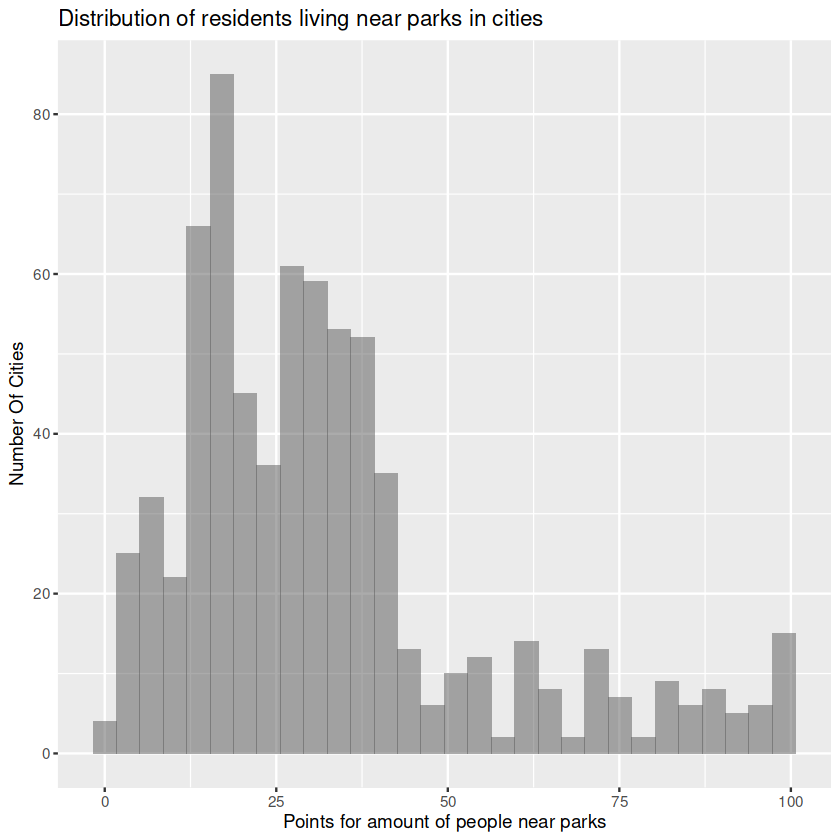

In [7]:
p1 <- favstats(~ pct_near_park_points, data = parks)

p2 <- gf_histogram( ~ pct_near_park_points, data = parks) |> 
  gf_labs(x = "Points for amount of people near parks",
       y = "Number Of Cities", 
       title = "Distribution of residents living near parks in cities")

p1
p2

- Use the visualization and summary statistics to describe the distribution of `pct_near_park_points`. Recall from the previous exercise the components to include in the description.

The dataset shows a skewed left bell curve with the mean at 32 and the median 28 with outliers going all the way to %100 of people near parks.

---
## Exercise 7
The `parks` data set ranges from the year 2012 to 2020, so each row contains information about funding and public amenities for each city in a given year. Thus, there are multiple rows in `parks` for each city. We are going to summarize the data, so there is just one row per city. Fill in the code below to create a new data frame called `parks_summary` that contains the mean spending per resident and mean points in the ParkScore index for the percent of residents within a 10-minute walk to a park.

In [8]:
# Insert code here
parks_summary <- parks |> # insert data set
  group_by(city) |> # insert name of variable you want to group by
  summarise(mean_spend = mean(spend_per_resident_data), # insert name of variable you want to compute the mean of
            mean_pts_near = mean (pct_near_park_points))  # use the previous line to do the same with the second variable

How many rows are in `parks_summary`? How many columns? Hint: You may have to write some code to answer this question.

In [9]:
glimpse(parks_summary)

Rows: 102
Columns: 3
$ city          <chr> "Albuquerque", "Anaheim", "Anchorage", "Arlington, Texas…
$ mean_spend    <dbl> 62.38222, 79.57143, 89.00000, 87.79125, 254.60000, 117.4…
$ mean_pts_near <dbl> 42.611111, 29.071429, 37.833333, 21.687500, 63.100000, 3…


There are 102 rows in parks summary and 3 columns.

---
## Exercise 8
- Create a visualization of the relationship between `mean_spend` and `mean_pts_near`, and calculate the correlation between the two variables. Include an informative title and informative axis labels on the visualization.

<div style="border:2px solid #b71c1c; background-color:#ffebee; padding:1em; border-radius:6px; color:#212121;">

**Feedback — Exercise 8**  <br>
What I saw: A <code>ggformula</code> scatterplot with informative labels and a qualitative description.  <br>
What’s missing or off: The numeric correlation was not computed or briefly interpreted.  <br>
How to improve: Compute correlation and add a one-sentence interpretation. Example code:  <br>
<code>cor(mean_spend ~ mean_pts_near, data = parks_summary)</code>  <br>
Then write something like: "Correlation is positive and of moderate strength, indicating higher near-park points tend to align with higher spending."  <br>
Why it matters: Quantifying association complements the visual and strengthens your conclusion.
</div>

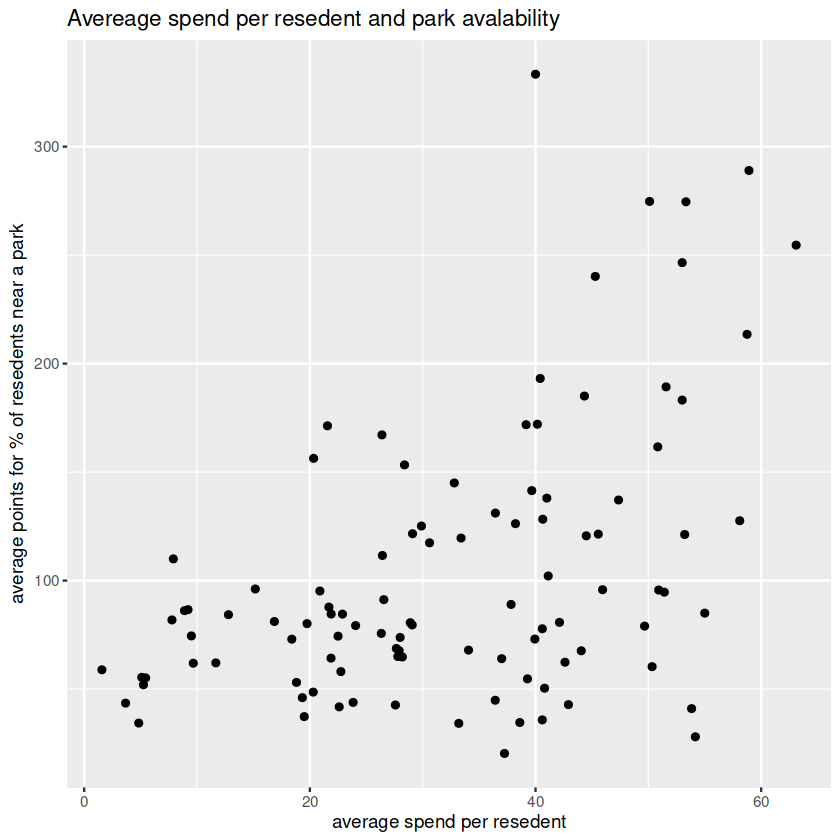

In [10]:
gf_point(mean_spend ~ mean_pts_near, data = parks_summary) |>
    gf_labs(x = "average spend per resedent",
       y = "average points for % of resedents near a park", 
       title = "Avereage spend per resedent and park avalability")

- Use the visualization and correlation to describe the relationship between the two variables. Include the shape, direction, strength, presence of potential outliers, and any other interesting features in the description.

The scatterplot shows a somewhat linear relationship between the average amount spent per resedent and how accessable the parks actually are to people. The problem is there are quite a few outliers who have large amounts of spending with very low accesability.

---
## Exercise 9
- Fit and display a linear regression model of the relationship between `mean_spend` and `mean_pts_near`.  Think carefully about which one should be the response variable. Use the `lm` function and display the model in a tidy format.

In [11]:
lmparks<-lm(mean_spend ~ mean_pts_near, data = parks_summary)

lmparks|>
tidy()

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),39.669325,13.184553,3.008773,3.319064e-03
mean_pts_near,1.965538,0.369642,5.317409,6.429797e-07


- Interpret the slope in the context of the data.

$\hat{B_1}$ =1.965538$X$ Or for each 1 point increase in park accessability there will be an extra $1.96 spent on average per resedent

- Interpret the intercept in the context of the data. Is the interpretation useful in practice for this data? Briefly explain.

$\hat{B_0}$=39.66935 Or if zero resedents live near the park there would be an average of $39.66 spent 

---
## Exercise 10
[*Parks and an Equitable Recovery*](https://www.tpl.org/parks-and-an-equitable-recovery-parkscore-report), a special report by Trust for Public Land, begins with the following conclusion from their analysis:

> *Our data shows major disparities in access to the outdoors. In the 100 most populated cities, neighborhoods where most residents identify as Black, Hispanic and Latinx, American Indian/Alaska Native or Asian American and Pacific Islander have access to an average of 44 percent less park acreage than predominantly white neighborhoods, and similar park space inequities exist in low-income neighborhoods across cities, highlighting the urgent need to center equity in park investment and planning.*

Would it be possible to reproduce the analysis results that led to this conclusion given the data we have in `parks.csv`? If so, briefly describe the steps we might take to reproduce the analysis. If not, briefly describe the additional data we need in order to reproduce the analysis.

We could not produce this analysis without more data. We would need data at a neighborhood and city level on ethnicity information within these neighborhoods as well as all the data we had previously but at a neighborhood level, we also would need access to size of park acreage.

# Grading (17 pts)
| Component             | Points |
|:----------------------|:-------|
| Ex 1                  | 1      |
| Ex 2                  | 1      |
| Ex 3                  | 1      |
| Ex 4                  | 1      |
| Ex 5                  | 1      |
| Ex 6                  | 2      |
| Ex 7                  | 2      |
| Ex 8                  | 2      |
| Ex 9                  | 3      |
| Ex 10                 | 1      |
| Grammar & Writing     | 1      |
| Workflow & formatting | 1      |

[^1]: The "Grammar & Writing" grade is decided based on your grammar and writing. This is typically decided by choosing one of the questions and assessing the writing.
[^2]: The "Workflow & formatting" grade is to assess the reproducible workflow and document format. This includes having a neatly organized document with readable code and your name and the date in the YAML.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a2556d82-89ae-4052-aafa-5abe5dc38127' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>